## Compute and visualize sentence-level similarities between ground-truth and generated sentences using a heatmap
1. Compute pairwise cosine similarity.
2. Plot a heatmap of similarities.

This notebook is setup to select an INDEX that will choose a generated text sample that was manually selected from the generated results data.  There were 5 samples selected, so the INDEX supports a value from 0-4 to select a generated text from the baseline, CoT ICD Code Semantic Search, CoT Knowled Graph (KG), and CoT ICD Code Semantic Search KG.  A sentence-level heatmap is used to compare the results side-by-side with the other prompt results.

<hr style="height:0.1rem;">

### Imports

In [1]:
from sentence_transformers import SentenceTransformer, models, util

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to D:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
import warnings
warnings.filterwarnings("ignore")

import logging
from transformers import logging as transformers_logging

# Suppress specific logs from transformers
transformers_logging.set_verbosity_error()

<hr style="height:0.1rem;">

### Function Declarations

In [3]:
def plot_sentence_similarity_heatmap(
    ground_truth_sentences, 
    generated_sentences, 
    model, 
    title="Sentence Similarity: Ground Truth vs Generated"
):
    """
    Plots a heatmap of cosine similarities between ground truth and generated sentences.

    Parameters:
    - ground_truth_sentences (list of str): Reference sentences.
    - generated_sentences (list of str): Sentences to compare against the ground truth.
    - model (obj): The SentenceTransformer model to use.
    - title (str): Title for the plot.
    """
    # Ensure both lists are of the same length
    min_len = min(len(ground_truth_sentences), len(generated_sentences))
    gt = ground_truth_sentences[:min_len]
    gen = generated_sentences[:min_len]

    # Encode sentence embeddings
    gt_embeddings = model.encode(gt, convert_to_tensor=True)
    gen_embeddings = model.encode(gen, convert_to_tensor=True)

    # Compute cosine similarity for each pair
    similarities = [util.cos_sim(g1, g2).item() for g1, g2 in zip(gt_embeddings, gen_embeddings)]

    # Convert to heatmap-friendly matrix
    similarity_matrix = np.array(similarities).reshape((min_len, 1))

    # Plot heatmap
    plt.figure(figsize=(6, 6))
    sns.heatmap(similarity_matrix, annot=True, cmap='Blues',
                xticklabels=["Similarity"],
                yticklabels=[f"Pair {i+1}" for i in range(min_len)])
    
    plt.title(title)
    plt.xlabel("Generated Text")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()

In [4]:
def plot_sentence_similarities(ground_truth, generated_sets, titles, model):
    """
    Plots cosine similarity heatmaps between ground truth sentences and multiple generated sets.

    Parameters:
    - ground_truth (list of str): Reference sentences.
    - generated_sets (list of list of str): A list containing multiple generated sentence lists.
    - model (SentenceTransformer): Pre-loaded SentenceTransformer model.
    """
    # Find minimum common length
    lengths = [len(ground_truth)] + [len(gen) for gen in generated_sets]
    min_len = min(lengths)

    # Trim all sets to the same length
    gt_trimmed = ground_truth[:min_len]
    gens_trimmed = [gen[:min_len] for gen in generated_sets]

    # Encode ground truth
    gt_embeddings = model.encode(gt_trimmed, convert_to_tensor=True)

    # Set up heatmaps
    num_sets = len(generated_sets)
    fig, axes = plt.subplots(1, num_sets, figsize=(5 * num_sets, 6))
    if num_sets == 1:
        axes = [axes]

    for idx, gen_set in enumerate(gens_trimmed):
        # Encode generated sentences
        gen_embeddings = model.encode(gen_set, convert_to_tensor=True)

        # Compute cosine similarities
        similarities = [util.cos_sim(gt, gen).item() for gt, gen in zip(gt_embeddings, gen_embeddings)]

        # Reshape to column vector
        sim_matrix = np.array(similarities).reshape(min_len, 1)

        # Plot heatmap
        sns.heatmap(sim_matrix, annot=True, cmap="Blues", cbar=False,
                    xticklabels=[f"{titles[idx]}"],
                    yticklabels=[f"Pair {i + 1}" for i in range(min_len)],
                    ax=axes[idx])
        axes[idx].set_title("Ground Truth vs " + titles[idx])

    plt.tight_layout()
    plt.show()

<hr style="height:0.1rem;">

### Load the base BERT model

##### Apply pooling strategy to get sentence-level embeddings

- [BERT](https://huggingface.co/google-bert/bert-large-uncased) - pretrained on a large corpus of English data in a self-supervised fashion
- [SciBERT](https://huggingface.co/allenai/scibert_scivocab_uncased) - pretrained BERT model trained on scientific text

In [5]:
#word_embedding_model = models.Transformer('bert-large-uncased')
word_embedding_model = models.Transformer('allenai/scibert_scivocab_uncased')
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())

model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

<hr style="height:0.1rem;">

### Ground-Truth - Clinical Case B in Paper

In [6]:
CLINICAL_CASE_B_ARTICLE_ID = 'S1130-05582017000100031-1'
CLINICAL_CASE_B_TEXT_REFERENCES = ['edentulism']
CLINICAL_CASE_B_ICD_CODES = ['K08109']
CLINICAL_CASE_B_PATIENT_AGE = '54'
CLINICAL_CASE_B_PATIENT_GENDER = 'female'
CLINICAL_CASE_B_CLINICAL_NOTES = '''A 54-year-old female patient was diagnosed with partial edentulism of both arches and severe alveolar sequestration class III of Sept1 in the edentulous premaxilla region. The treatment plan consists of placing two hydrogel pearls sterilized in an autoclave for tissue expansion of the premaxilla, and a subsequent block bone allograft in the same place. Two weeks after the placement of hydrogel pearls, exposure and removal of them were performed, with placement of medium wound block was possible discharge stereotactic marking, not preformed translithotomy incisions and tension could be performed. Once the healing phase of the block finished, the dental implants were placed in an appropriate position, with very good bone rehabilitation and blocking.'''

In [7]:
SNOMED_CT_ONTOLOGY = """
ICD Code: K08109
Ontology Concept Definition:

Concept: Edentulous (finding) (278650002)
Subclass of: Clinical finding (finding) (404684003), Role group (attribute) (609096000), Has interpretation (attribute) (363713009), Absent (qualifier value) (2667000), Interprets (attribute) (363714003), Tooth presence (observable entity) (278652005), Role group (attribute) (609096000), Finding site (attribute) (363698007), All teeth (body structure) (1162715001)
"""

In [8]:
ground_truth_sentences = sent_tokenize(CLINICAL_CASE_B_CLINICAL_NOTES)
ground_truth_sentences

['A 54-year-old female patient was diagnosed with partial edentulism of both arches and severe alveolar sequestration class III of Sept1 in the edentulous premaxilla region.',
 'The treatment plan consists of placing two hydrogel pearls sterilized in an autoclave for tissue expansion of the premaxilla, and a subsequent block bone allograft in the same place.',
 'Two weeks after the placement of hydrogel pearls, exposure and removal of them were performed, with placement of medium wound block was possible discharge stereotactic marking, not preformed translithotomy incisions and tension could be performed.',
 'Once the healing phase of the block finished, the dental implants were placed in an appropriate position, with very good bone rehabilitation and blocking.']

<hr style="height:0.1rem;">

### Sample

In [9]:
sent1 = "A 54-year-old female patient was diagnosed with partial edentulism of both arches and severe alveolar sequestration class III of Sept1 in the edentulous premaxilla region"
sent2 = "The 54-year-old female patient presents with complaints of tooth loss."

emb1 = model.encode(sent1, convert_to_tensor=True)
emb2 = model.encode(sent2, convert_to_tensor=True)

similarity = util.pytorch_cos_sim(emb1, emb2)
print(f"Sentence similarity: {similarity.item():.4f}")

Sentence similarity: 0.8542


<hr style="height:0.1rem;">

### Settings

In [10]:
# Set a value between 0-4
BASELINE_GENERATED_TEXT_INDEX = 0

In [11]:
# Set a value between 0-4
COTSS_GENERATED_TEXT_INDEX = 0

In [12]:
# Set a value between 0-4
COTKG_GENERATED_TEXT_INDEX = 0

In [13]:
# Set a value between 0-4
COTSSKG_GENERATED_TEXT_INDEX = 0

<hr style="height:0.1rem;">

### Baseline

Contains: 
- ICD Codes
- Patient Age
- Patient Gender

In [14]:
### R003 means row #3 in the CSV (includes header row as Row 1)
BASELINE_R003_GENERATED_TEXT = """The 54-year-old female patient presents with complaints of tooth loss. She reports that she has lost several teeth over the past few years, not related to any trauma or injury. She also mentions experiencing difficulty in chewing and occasional discomfort due to the missing teeth. She denies any associated pain, swelling, or signs of infection. She has not sought any dental intervention for the tooth loss until now. Her oral hygiene practices are fair, but she admits to not visiting a dentist regularly. She does not have any known allergies or significant medical history. She does not smoke or consume alcohol. Further evaluation and management are planned to address her tooth loss, coded as K08.109."""
BASELINE_R041_GENERATED_TEXT = """The 54-year-old female patient presents with complaints of tooth loss. She reports that she has lost several teeth over the past few months without any apparent cause such as trauma or decay. She denies any associated pain, swelling, or discomfort. She also denies any changes in her eating habits, oral hygiene, or use of tobacco products. She has no history of periodontal disease or other oral health issues. She is concerned about the aesthetic and functional implications of her tooth loss."""
BASELINE_R068_GENERATED_TEXT = """The patient is a 54-year-old female who presents with complaints of tooth loss. She reports that she has lost several teeth over the past few months without any apparent reason. She denies any associated pain, swelling, or infection. She also denies any recent trauma or injury to the mouth. She does not wear dentures. She has not sought any dental care for this issue yet. She does not have any significant medical history. She does not smoke and drinks alcohol occasionally. She maintains good oral hygiene. Her diet is balanced and she does not have any known allergies."""
BASELINE_R088_GENERATED_TEXT = """The patient is a 54-year-old female who presents with complaints of tooth loss. She reports that she has lost several teeth over the past few months without any apparent reason such as trauma or decay. She denies any associated pain, swelling, or infection. She also denies any changes in her eating habits, oral hygiene, or use of tobacco products. She has not sought any dental care for this issue yet. She is concerned about the impact of this tooth loss on her appearance and ability to chew food properly. Further evaluation and management are needed to address her tooth loss, coded as K08.109."""
BASELINE_R096_GENERATED_TEXT = """The 54-year-old female patient presents with complaints of tooth loss. She reports that she has lost several teeth over the past few months without any apparent cause such as trauma or decay. She denies any associated pain, swelling, or discomfort. She also denies any recent changes in her diet or oral hygiene habits. She is concerned about the aesthetic and functional implications of her tooth loss. She has no known allergies and is currently not on any medications. She does not smoke or drink alcohol. Her past medical history is unremarkable."""

# Add selected sentences to list
BASELINE_GENERATED_TEXTS = [
    BASELINE_R003_GENERATED_TEXT,
    BASELINE_R041_GENERATED_TEXT,
    BASELINE_R068_GENERATED_TEXT,
    BASELINE_R088_GENERATED_TEXT,
    BASELINE_R096_GENERATED_TEXT
]

# Convert Baseline to sentences
baseline_sentences = sent_tokenize(BASELINE_GENERATED_TEXTS[BASELINE_GENERATED_TEXT_INDEX])
baseline_sentences

['The 54-year-old female patient presents with complaints of tooth loss.',
 'She reports that she has lost several teeth over the past few years, not related to any trauma or injury.',
 'She also mentions experiencing difficulty in chewing and occasional discomfort due to the missing teeth.',
 'She denies any associated pain, swelling, or signs of infection.',
 'She has not sought any dental intervention for the tooth loss until now.',
 'Her oral hygiene practices are fair, but she admits to not visiting a dentist regularly.',
 'She does not have any known allergies or significant medical history.',
 'She does not smoke or consume alcohol.',
 'Further evaluation and management are planned to address her tooth loss, coded as K08.109.']

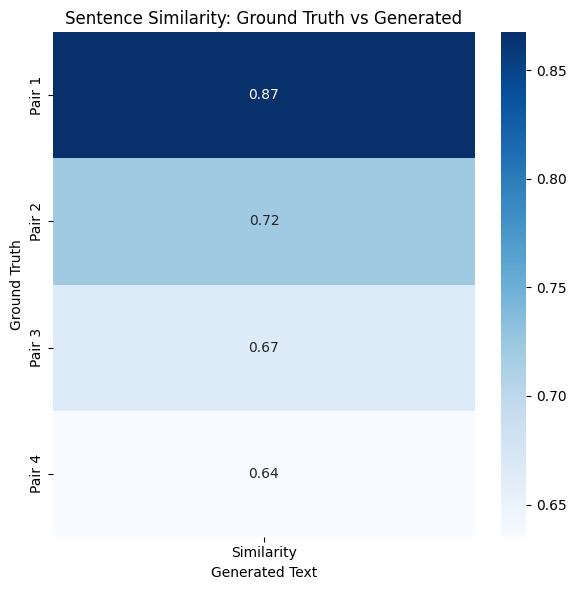

In [15]:
plot_sentence_similarity_heatmap(
    ground_truth_sentences, 
    baseline_sentences,
    model
)

<hr style="height:0.1rem;">

### CoT ICD Code Semantic Search

Contains: 
- ICD Codes
- Patient Age
- Patient Gender
- Similar Clinical Example (10 cases) based on ICD Codes

In [16]:
### R057 means row #57 in the CSV (includes header row as Row 1)
COTSS_R005_GENERATED_TEXT = """A 54-year-old female patient presents with a complaint of discomfort in the oral cavity. Upon examination, it is noted that the patient has partial maxillomandibular edentulism, with signs of generalized chronic periodontal disease. There is also an increase in volume in the glomus floor space, which is bilateral. The patient reports a history of controlled hypertension and chronic kidney disease stage V, which has been managed with hemodialysis three times a week. The patient also reports experiencing dysphagia and an increase in volume in the jawbone area and upper limb. The patient's medical history and physical examination suggest a need for further investigation and treatment."""
COTSS_R044_GENERATED_TEXT = """The patient is a 54-year-old female who presents with complaints of discomfort in the oral cavity. Upon examination, there is evidence of partial maxillomandibular edentulism and generalized chronic periodontal disease. The patient also reports halitosis and an increase in volume in the glomus floor space. The patient's medical history reveals controlled hypertension and chronic kidney disease stage V, which has been managed with hemodialysis three times a week. The patient has been experiencing dysphagia and swelling in the jawbone area and upper limb. The patient is currently undergoing treatment with crystalline sodium penicillin and aztreonam. Further evaluation and management are planned in conjunction with the departments of Infectious Diseases and Internal Medicine."""
COTSS_R057_GENERATED_TEXT = """A 54-year-old female patient presents with complaints of discomfort in the oral cavity. Upon examination, it is noted that the patient has partial maxillomandibular edentulism, with signs of generalized chronic periodontal disease. There is also an increase in volume in the glomus floor space bilaterally. The patient reports a history of controlled hypertension and is currently undergoing hemodialysis three times a week due to chronic kidney disease stage V. The patient also reports experiencing dysphagia and an increase in volume in the jawbone area and upper limb. Further examination reveals sclera iccas and a severe increase in volume with predominance in the bilateral submental and submandibular regions. The patient's mouth opening is limited to approximately 15 mm. The presence of local irritants and halitosis is also noted. The patient is referred for further diagnostic tests and treatment planning."""
COTSS_R074_GENERATED_TEXT = """The patient is a 54-year-old female who presents with complaints of discomfort in the oral cavity. Upon examination, there is evidence of partial maxillomandibular edentulism and generalized chronic periodontal disease. The patient also reports halitosis and an increase in volume in the glomus floor space. The patient's medical history reveals controlled hypertension and chronic kidney disease stage V, which has been managed with hemodialysis three times a week. The patient has been experiencing dysphagia and swelling in the jawbone area and upper limb. The patient is currently undergoing treatment with crystalline sodium penicillin and aztreonam, administered intravenously. The patient's condition is being closely monitored by the departments of Infectious Diseases and Internal Medicine. The patient's condition is currently stable, but the evolution of the disease has been slow and challenging. The patient is scheduled for extraction of the affected teeth and surgical drainage of the sublingual, submandibular, and submental spaces. The patient's condition is expected to improve following the surgical intervention."""
COTSS_R095_GENERATED_TEXT = """A 54-year-old female patient presents with complaints of discomfort in the oral cavity. Upon examination, there is evidence of partial maxillomandibular edentulism and generalized chronic periodontal disease. The patient also reports halitosis and an increase in volume in the glomus floor space. The patient's medical history reveals controlled hypertension and chronic kidney disease stage V, which has been managed with hemodialysis three times a week. The patient has been experiencing dysphagia and swelling in the jawbone area and upper limb. The patient's sclera appears icteric. The patient is currently undergoing treatment with crystalline sodium penicillin and aztreonam, administered intravenously. A computed tomography scan reveals an isodense image in the parapharyngeal space, consistent with increased volume, and a diagnosis of Ludwig's angina is made. The patient's condition remains torpid after 10 days of treatment, and a reassessment leads to the initiation of intravenous vancomycin, which results in significant clinical improvement. After systemic stabilization, extraction of the affected teeth is performed, along with surgical drainage of the sublingual, submandibular, and submental spaces. The patient's condition improves with antibiotic therapy"""

# Add selected sentences to list
COTSS_GENERATED_TEXTS = [
    COTSS_R005_GENERATED_TEXT,
    COTSS_R044_GENERATED_TEXT,
    COTSS_R057_GENERATED_TEXT,
    COTSS_R074_GENERATED_TEXT,
    COTSS_R095_GENERATED_TEXT
]

# Convert CoT ICD Semantic Search to sentences
cotss_sentences = sent_tokenize(COTSS_GENERATED_TEXTS[COTSS_GENERATED_TEXT_INDEX])
cotss_sentences

['A 54-year-old female patient presents with a complaint of discomfort in the oral cavity.',
 'Upon examination, it is noted that the patient has partial maxillomandibular edentulism, with signs of generalized chronic periodontal disease.',
 'There is also an increase in volume in the glomus floor space, which is bilateral.',
 'The patient reports a history of controlled hypertension and chronic kidney disease stage V, which has been managed with hemodialysis three times a week.',
 'The patient also reports experiencing dysphagia and an increase in volume in the jawbone area and upper limb.',
 "The patient's medical history and physical examination suggest a need for further investigation and treatment."]

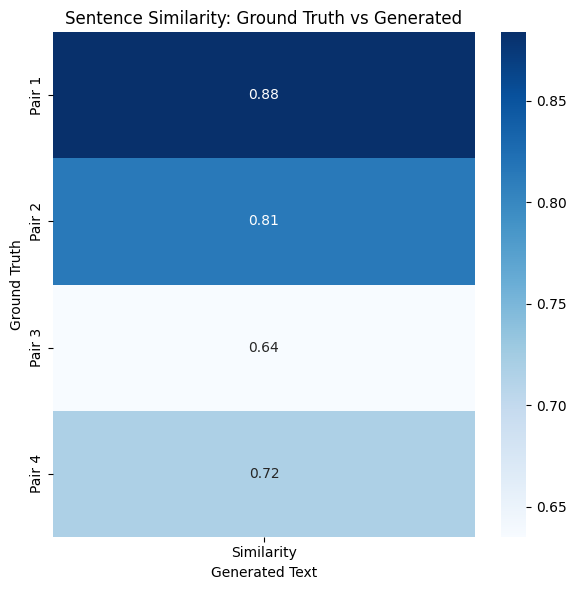

In [17]:
plot_sentence_similarity_heatmap(
    ground_truth_sentences, 
    cotss_sentences,
    model
)

<hr style="height:0.1rem;">

### CoT Knowledge Graph (KG)

Contains: 
- ICD Codes
- Patient Age
- Patient Gender
- SNOMED-CT Ontology

In [18]:
### R009 means row #9 in the CSV (includes header row as Row 1)
COTKG_R009_GENERATED_TEXT = """History of Present Illness: The patient is a 54-year-old female who presents with a complete absence of teeth. She reports having lost all her teeth over the years due to various dental issues. She has not had any dental prosthetics or implants. She has been managing without teeth but is now finding it increasingly difficult to eat and speak properly. She also reports a decrease in self-confidence due to her appearance."""
COTKG_R028_GENERATED_TEXT = """History of Present Illness: The patient is a 54-year-old female who presents with a complete absence of teeth. She reports having lost all her teeth over the years due to various dental issues. She has not had any dental prosthetics or implants. The patient's edentulous condition has been affecting her ability to chew food properly and has been causing her discomfort. She is seeking options for treatment to improve her oral function and appearance."""
COTKG_R042_GENERATED_TEXT = """History of Present Illness: The 54-year-old female patient presents with a complete absence of teeth. She has been edentulous for some time now. The patient reports no presence of any teeth in the oral cavity. This condition has been interpreted as a clinical finding."""
COTKG_R069_GENERATED_TEXT = """History of Present Illness: The patient is a 54-year-old female who presents with complete tooth loss. She reports that she has been without teeth for several years now. She has not had any dental prosthetics in the past and has been managing with her current condition. She denies any recent changes in her oral health. She does not report any pain, discomfort, or difficulty in eating or speaking. However, she expresses concern about her appearance and is interested in possible solutions for her edentulous condition."""
COTKG_R084_GENERATED_TEXT = """History of Present Illness: The patient is a 54-year-old female who presents with complete tooth loss. She reports that she has been without teeth for several years now. She has not had any dental prosthetics fitted and has been managing with her current condition. She denies any recent changes in her oral health. She does not report any pain, discomfort, or difficulty in eating or speaking. She has not noticed any changes in her facial appearance or speech. She is seeking dental care for the first time in many years."""

# Add selected sentences to list
COTKG_GENERATED_TEXTS = [
    COTKG_R009_GENERATED_TEXT,
    COTKG_R028_GENERATED_TEXT,
    COTKG_R042_GENERATED_TEXT,
    COTKG_R069_GENERATED_TEXT,
    COTKG_R084_GENERATED_TEXT
]

# Convert CoT KG to sentences
cotkg_sentences = sent_tokenize(COTKG_GENERATED_TEXTS[COTKG_GENERATED_TEXT_INDEX])
cotkg_sentences

['History of Present Illness: The patient is a 54-year-old female who presents with a complete absence of teeth.',
 'She reports having lost all her teeth over the years due to various dental issues.',
 'She has not had any dental prosthetics or implants.',
 'She has been managing without teeth but is now finding it increasingly difficult to eat and speak properly.',
 'She also reports a decrease in self-confidence due to her appearance.']

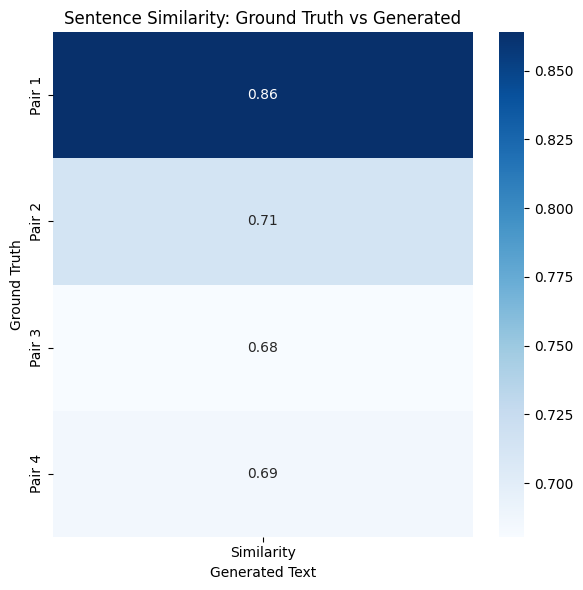

In [19]:
plot_sentence_similarity_heatmap(
    ground_truth_sentences, 
    cotkg_sentences,
    model
)

<hr style="height:0.1rem;">

### CoT ICD Code Semantic Search Knowledge Graph (KG)

Contains: 
- ICD Codes
- Patient Age
- Patient Gender
- Similar Clinical Example (10 cases) based on ICD Codes
- SNOMED-CT Ontology

In [20]:
### R006 means row #6 in the CSV (includes header row as Row 1)
COTSSKG_R006_GENERATED_TEXT = """History of Present Illness: The patient is a 54-year-old female who presents with a history of edentulism. She reports having lost all her teeth over the years due to various dental issues. She has been managing with dentures but has been experiencing discomfort and difficulty with chewing. She denies any recent trauma, infections, or significant weight loss. She has not noticed any changes in her sense of taste or any oral lesions. She does not smoke or drink alcohol. She has been maintaining good oral hygiene and regularly visits her dentist for check-ups. She is seeking consultation for possible dental implant options to improve her quality of life."""
COTSSKG_R033_GENERATED_TEXT = """The patient is a 54-year-old female who presents with a complete absence of teeth. She reports having lost her teeth over the years due to various dental issues and has not sought replacement options. She has been managing with a soft diet and has not experienced significant discomfort or difficulty with her current state of edentulism. However, she is now considering options for dental prosthetics for aesthetic reasons and to improve her ability to chew a wider variety of foods. She denies any current oral pain, swelling, or other symptoms. She has no known allergies and her medical history is unremarkable."""
COTSSKG_R051_GENERATED_TEXT = """The patient is a 54-year-old female who presents with a complete absence of teeth. She reports having lost her teeth over the years due to various dental issues. She has been managing with dentures but has been experiencing discomfort and difficulty with chewing. She denies any recent trauma, infections, or significant medical history. On physical examination, she is found to be completely edentulous with no signs of oral lesions or inflammation. She expresses interest in exploring options for dental implants."""
COTSSKG_R065_GENERATED_TEXT = """History of Present Illness: The patient is a 54-year-old female who presents with a history of edentulism. She reports having lost all her teeth over the years due to various dental issues. She has been managing with dentures but has been experiencing discomfort and difficulty in eating. She denies any recent trauma, infection, or significant weight loss. She has no history of oral cancer or any systemic diseases affecting the oral cavity. She does not smoke or consume alcohol. She is seeking consultation for possible dental implants for better comfort and functionality."""
COTSSKG_R078_GENERATED_TEXT = """The patient is a 54-year-old female who presents with a complete absence of teeth. She reports having lost her teeth over the years due to various dental issues and has not sought out dental prosthetics or implants. She denies any current oral pain or discomfort, but does express concern about her ability to eat certain foods and the impact on her overall appearance. She is interested in exploring options for restoring her dentition. Physical examination confirms edentulism, with no signs of oral infection or other abnormalities."""

# Add selected sentences to list
COTSSKG_GENERATED_TEXTS = [
    COTSSKG_R006_GENERATED_TEXT,
    COTSSKG_R033_GENERATED_TEXT,
    COTSSKG_R051_GENERATED_TEXT,
    COTSSKG_R065_GENERATED_TEXT,
    COTSSKG_R078_GENERATED_TEXT
]

# Convert CoT KG to sentences
cotsskg_sentences = sent_tokenize(COTSSKG_GENERATED_TEXTS[COTSSKG_GENERATED_TEXT_INDEX])
cotsskg_sentences

['History of Present Illness: The patient is a 54-year-old female who presents with a history of edentulism.',
 'She reports having lost all her teeth over the years due to various dental issues.',
 'She has been managing with dentures but has been experiencing discomfort and difficulty with chewing.',
 'She denies any recent trauma, infections, or significant weight loss.',
 'She has not noticed any changes in her sense of taste or any oral lesions.',
 'She does not smoke or drink alcohol.',
 'She has been maintaining good oral hygiene and regularly visits her dentist for check-ups.',
 'She is seeking consultation for possible dental implant options to improve her quality of life.']

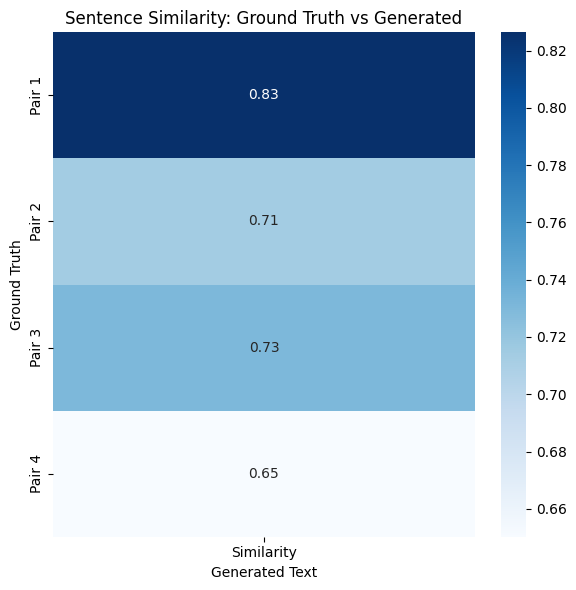

In [21]:
plot_sentence_similarity_heatmap(
    ground_truth_sentences, 
    cotsskg_sentences,
    model
)

<hr style="height:0.1rem;">

### Compare multiple results

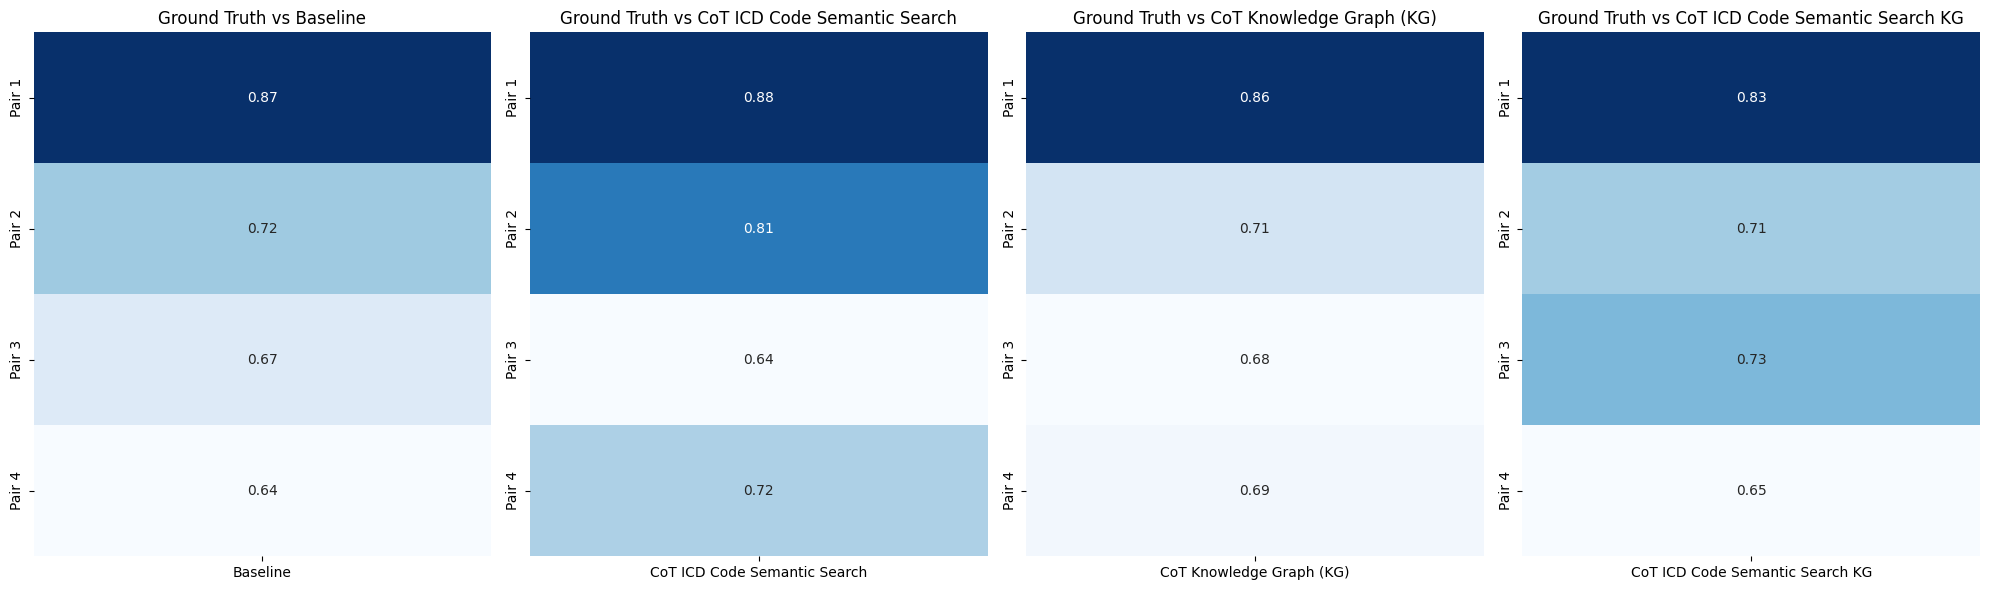

In [22]:
lists = [
    baseline_sentences,
    cotss_sentences,
    cotkg_sentences,
    cotsskg_sentences
]
titles = [
    'Baseline',
    'CoT ICD Code Semantic Search',
    'CoT Knowledge Graph (KG)',
    'CoT ICD Code Semantic Search KG'
]
plot_sentence_similarities(ground_truth_sentences, lists, titles, model)

<hr style="height:1rem;">

### Assessement #1

#### Settings
- BASELINE_GENERATED_TEXT_INDEX = 0
- COTSS_GENERATED_TEXT_INDEX = 0
- COTKG_GENERATED_TEXT_INDEX = 0
- COTSSKG_GENERATED_TEXT_INDEX = 0

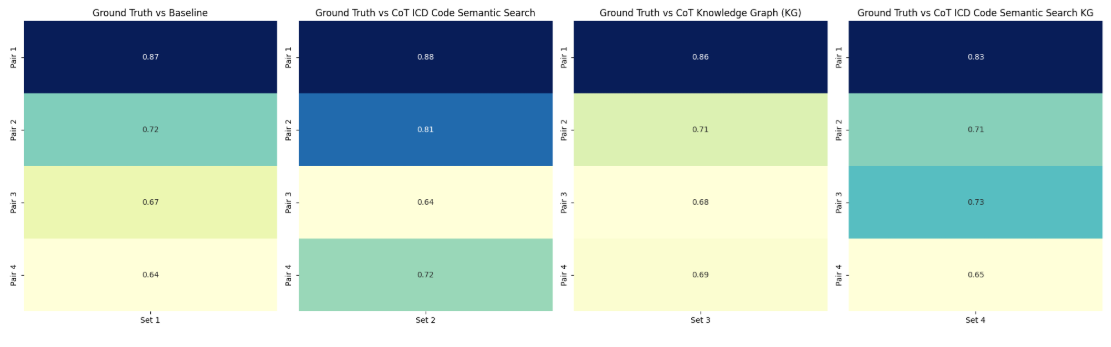

Looking at Sentence 2 in the ```ICD Code Semantic Search``` which scores ```0.81```, we see a match of the ```edentulism``` in the Text Reference:

Sentence 2: ```Upon examination, it is noted that the patient has partial maxillomandibular edentulism, with signs of generalized chronic periodontal disease.```

Looking at Sentence 3 in the ```ICD Code Semantic Search KG``` which scores ```0.73```, it's unclear why it scores high with words ```trauma```, ```infections```, and ```weight loss```.

Sentence 3: ```She denies any recent trauma, infections, or significant weight loss.```

<hr style="height:0.1rem;">

### Assessement #2

#### Settings
- BASELINE_GENERATED_TEXT_INDEX = 1
- COTSS_GENERATED_TEXT_INDEX = 1
- COTKG_GENERATED_TEXT_INDEX = 1
- COTSSKG_GENERATED_TEXT_INDEX = 1

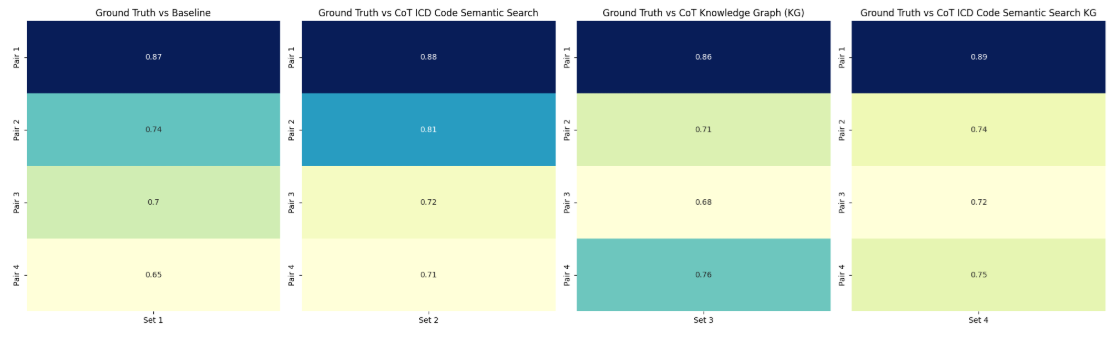

Looking at Sentence 2 in the ```ICD Code Semantic Search``` which scores ```0.81```, we see a match of the ```edentulism``` again in the Text Reference:

Sentence 2: ```Upon examination, there is evidence of partial maxillomandibular edentulism and generalized chronic periodontal disease```

<hr style="height:0.1rem;">

### Assessement #3

#### Settings
- BASELINE_GENERATED_TEXT_INDEX = 2
- COTSS_GENERATED_TEXT_INDEX = 2
- COTKG_GENERATED_TEXT_INDEX = 2
- COTSSKG_GENERATED_TEXT_INDEX = 2

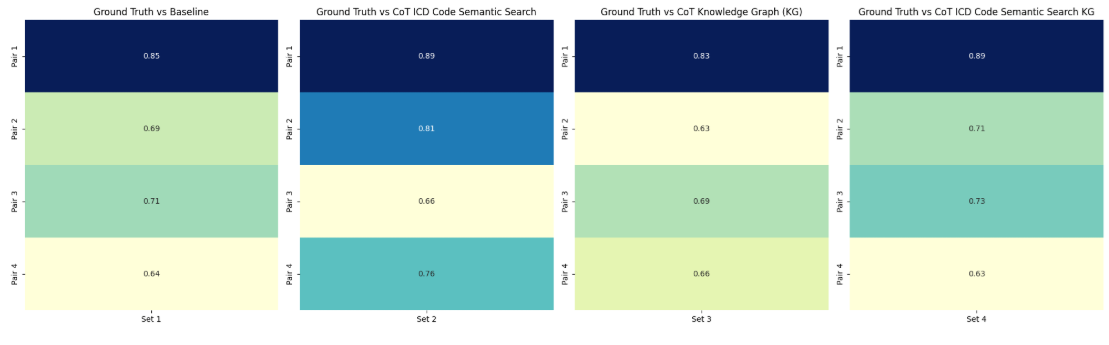

Looking at Sentence 2 in the ```ICD Code Semantic Search``` which scores ```0.81```, we see a match of the ```edentulism``` again in the Text Reference:

Sentence 2: ```Upon examination, it is noted that the patient has partial maxillomandibular edentulism, with signs of generalized chronic periodontal disease```

<hr style="height:0.1rem;">

### Assessement #4

#### Settings
- BASELINE_GENERATED_TEXT_INDEX = 3
- COTSS_GENERATED_TEXT_INDEX = 3
- COTKG_GENERATED_TEXT_INDEX = 3
- COTSSKG_GENERATED_TEXT_INDEX = 3

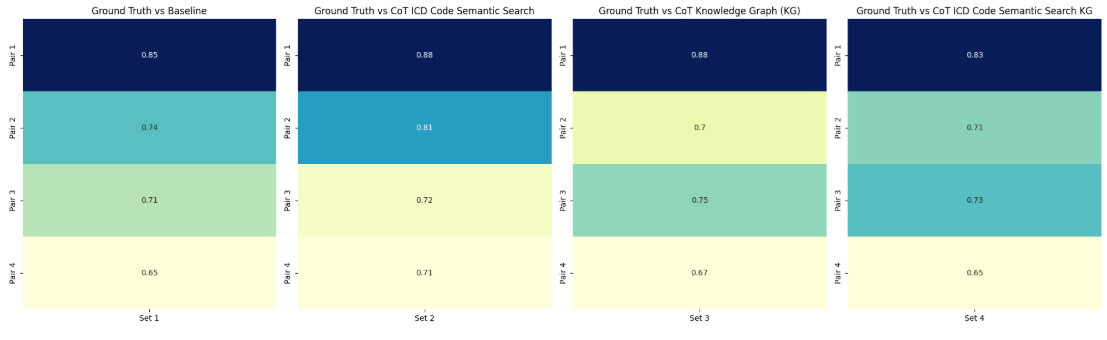

Looking at Sentence 2 in the ```ICD Code Semantic Search``` which scores ```0.81```, we see a match of the ```edentulism``` again in the Text Reference:

Sentence 2: ```Upon examination, there is evidence of partial maxillomandibular edentulism and generalized chronic periodontal disease.```

<hr style="height:0.1rem;">

### Assessement #5

#### Settings
- BASELINE_GENERATED_TEXT_INDEX = 4
- COTSS_GENERATED_TEXT_INDEX = 4
- COTKG_GENERATED_TEXT_INDEX = 4
- COTSSKG_GENERATED_TEXT_INDEX = 4

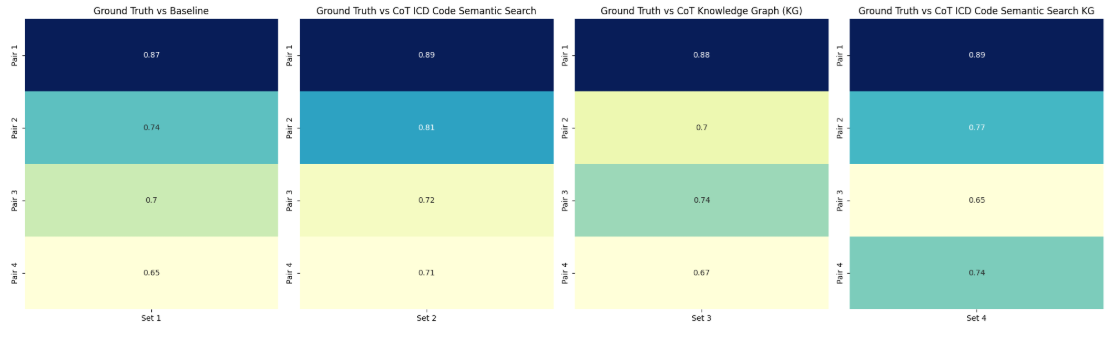

Looking at Sentence 2 in the ```ICD Code Semantic Search``` which scores ```0.81```, we see a match of the ```edentulism``` again in the Text Reference:

Sentence 2: ```Upon examination, there is evidence of partial maxillomandibular edentulism and generalized chronic periodontal disease.```

Looking at Sentence 3 in ```ICD Code Semantic Search KG``` which scores ```0.77```, we don't see a clear match in words, but ```teeth```, ```dental```, ```prosthetics``` and ```implants``` are seen.  Need to compare token-level

Sentence 2: ```She reports having lost her teeth over the years due to various dental issues and has not sought out dental prosthetics or implants.```


<hr style="height:0.5rem;">

### Overall Assessement

- For every prompt, the patient age and gender is handled correctly.  The first sentence scores the highest and it gradually declines in score, with a few exceptions.
- For the 5 CoT ICD Code Semantic Search generated text samples, sentence 2 contains ```edentulism``` in the generated text, which is found in the ground-truth text.
- Looking back at the Semantic Search examples for this particular clinical case B, there is no reference to ```edentulism``` in the clinical notes for the 10 similar examples
- Need to look at token-level and do an assessment, using the nouns.
